# **CV classification**

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [50]:
df = pd.read_csv('UpdatedResumeDataSet.csv')

In [51]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [52]:
def remove_stopwords(text):
    """
    Remove stopwords from a given text.
    Parameters:
        text (str): The input text from which to remove stopwords.
        language (str): The language of the stopwords. Default is 'english'.
    Returns:
        filtered_text (str): Text without stopwords.
    """

    stop_words = set([
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your",
    "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she",
    "her", "hers", "herself", "it", "its", "itself", "they", "them", "their",
    "theirs", "themselves", "what", "which", "who", "whom", "this", "that",
    "these", "those", "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an",
    "the", "and", "but", "if", "or", "because", "as", "until", "while", "of",
    "at", "by", "for", "with", "about", "against", "between", "into", "through",
    "during", "before", "after", "above", "below", "to", "from", "up", "down",
    "in", "out", "on", "off", "over", "under", "again", "further", "then",
    "once", "here", "there", "when", "where", "why", "how", "all", "any",
    "both", "each", "few", "more", "most", "other", "some", "such", "no",
    "nor", "not", "only", "own", "same", "so", "than", "too", "very", "s",
    "t", "can", "will", "just", "don", "should", "now"
    ])
    words = text.split()  # Simple tokenization by spaces
    filtered_words = [word for word in words if word.lower() not in stop_words]
    filtered_text = ' '.join(filtered_words)
    return filtered_text

In [53]:
def cleanResume(txt):
    """
    Clean the text in the resume i.e. remove unwanted chars in the text. For e.g.
    1 URLs,
    2 Hashtags,
    3 Mentions,
    4 Special Chars,
    5 Punctuations
    Parameters:
        resume_text (str): The input resume text to be cleaned.
    Returns:
        clean_text (str): Clean Resume.
    """
    cleanText = re.sub('http\S+\s', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub('\s+', ' ', cleanText)
    cleanText  = remove_stopwords(cleanText)
    return cleanText

In [54]:
df['Resume'] = df['Resume'].apply(lambda x: cleanResume(x))


In [55]:
le = LabelEncoder()

In [56]:
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])

In [57]:
# طباعة القيم الفعلية مع الأرقام المقابلة لها بعد الترميز
category_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(category_mapping)


{'Advocate': 0, 'Arts': 1, 'Automation Testing': 2, 'Blockchain': 3, 'Business Analyst': 4, 'Civil Engineer': 5, 'Data Science': 6, 'Database': 7, 'DevOps Engineer': 8, 'DotNet Developer': 9, 'ETL Developer': 10, 'Electrical Engineering': 11, 'HR': 12, 'Hadoop': 13, 'Health and fitness': 14, 'Java Developer': 15, 'Mechanical Engineer': 16, 'Network Security Engineer': 17, 'Operations Manager': 18, 'PMO': 19, 'Python Developer': 20, 'SAP Developer': 21, 'Sales': 22, 'Testing': 23, 'Web Designing': 24}


In [58]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf.fit(df['Resume'])
resumeTextTFIDF  = tfidf.transform(df['Resume'])

In [59]:
X_train, X_test, y_train, y_test = train_test_split(resumeTextTFIDF, df['Category'], test_size=0.2, random_state=42)

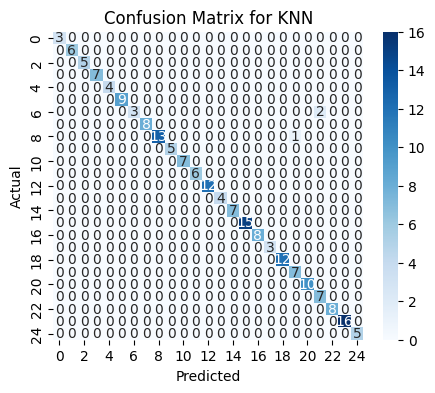

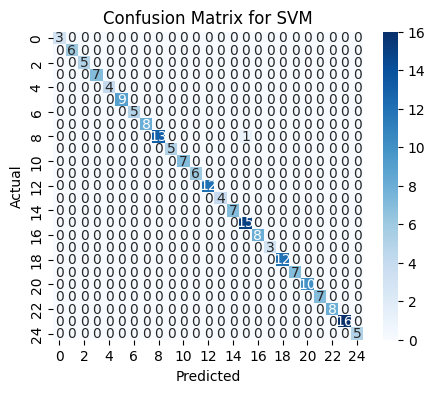

In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


classifiers = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
}

results = []
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    # Setting average='weighted' for multiclass classification
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])


    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues") #, xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {name}")
    plt.show()


df_results = pd.DataFrame(results, columns=["Classifier", "Accuracy", "Precision", "Recall", "F1-score"])

In [61]:
import joblib
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(classifiers["SVM"], "svm_model.pkl")
print("تم حفظ النموذج والمتحول بنجاح!")

تم حفظ النموذج والمتحول بنجاح!


In [62]:
# تحميل TfidfVectorizer
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

# تحميل نموذج SVM
loaded_svm = joblib.load("svm_model.pkl")

# تحويل نص جديد باستخدام `TfidfVectorizer`
new_resume = ["Software engineer with experience in Python and AI."]
new_resume_tfidf = loaded_tfidf.transform(new_resume)

# استخدام SVM للتنبؤ
prediction = loaded_svm.predict(new_resume_tfidf)

print("التصنيف المتوقع للسيرة الذاتية الجديدة:", prediction)


التصنيف المتوقع للسيرة الذاتية الجديدة: [6]


In [64]:
import joblib
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")
loaded_svm = joblib.load("svm_model.pkl")
category_mapping = {
    15: "Java Developer",
    23: "Testing",
    8: "DevOps Engineer",
    20: "Python Developer",
    24: "Web Designing",
    12: "HR",
    13: "Hadoop",
    3: "Blockchain",
    10: "ETL Developer",
    18: "Operations Manager",
    6: "Data Science",
    22: "Sales",
    16: "Mechanical Engineer",
    1: "Arts",
    7: "Database",
    11: "Electrical Engineering",
    14: "Health and fitness",
    19: "PMO",
    4: "Business Analyst",
    9: "DotNet Developer",
    2: "Automation Testing",
    17: "Network Security Engineer",
    21: "SAP Developer",
    5: "Civil Engineer",
    0: "Advocate",
}

new_resume = ["Software engineer with experience in Python and AI."]
new_resume_tfidf = loaded_tfidf.transform(new_resume)

prediction = loaded_svm.predict(new_resume_tfidf)[0]

category_name = category_mapping.get(prediction, "Unknown")

print("🔹 التصنيف المتوقع للسيرة الذاتية الجديدة:", category_name)


🔹 التصنيف المتوقع للسيرة الذاتية الجديدة: Data Science
